# Interest Rate Modelling: Vasicek & CIR Framework

## Overview

This section implements a short-rate modelling framework based on two classical affine term structure models:

- **Vasicek Model (Gaussian short-rate dynamics)**
- **Cox-Ingersoll-Ross (CIR) Model (positivity-constrained short rates)**

The objective is to simulate interest rate paths, analyze stochastic behavior under mean reversion, and derive bond pricing and yield curve dynamics under risk-neutral assumptions.

These models form the foundation of modern fixed income theory and are widely used in:
- Interest rate risk management
- Bond pricing and valuation
- Scenario generation for macro-financial stress testing
- Derivative pricing (interest rate options, swaps)

## Methodology

### 1. Vasicek Model (Ornstein-Uhlenbeck Process)

The Vasicek model assumes that short rates follow a mean-reverting Gaussian process:

- Rates revert to a long-term mean level  
- Closed-form tractability  
- Allows negative interest rates  

This model is used primarily for:
- Analytical tractability
- Scenario simulation
- Baseline interest rate dynamics

Key outputs:
- Single-path and Monte Carlo simulations
- Distribution of terminal rates
- Scenario selection (bullish / bearish rate paths)

---

### 2. CIR Model (Square-Root Diffusion Process)

The CIR model extends Vasicek by introducing a square-root diffusion term:

- Ensures strictly positive interest rates  
- Volatility scales with the level of rates  
- Satisfies the Feller condition for boundary behavior  

This makes it more suitable for:
- Realistic interest rate modelling  
- Long-term yield curve dynamics  
- Fixed income valuation consistency  

---

### 3. Zero-Coupon Bond Pricing (CIR Term Structure)

Under the CIR framework, zero-coupon bond prices admit a closed-form solution:

- Bond prices are expressed as exponential-affine functions of the short rate  
- Yield curves are derived as a transformation of bond prices  
- Allows full term structure construction from model parameters  

This enables:
- Theoretical yield curve generation  
- Comparison against observed market yields  
- Sensitivity analysis to mean reversion and volatility parameters  

## Outputs

This framework generates:

- Simulated short-rate paths (Vasicek and CIR)
- Monte Carlo distribution of interest rate outcomes
- Terminal rate scenario analysis (bullish / bearish regimes)
- CIR-implied zero-coupon bond prices
- Model-implied yield curves
- Comparison between theoretical and observed market yields

## Interpretation

This module provides a structural view of interest rate dynamics:

- Vasicek → linear mean reversion, analytically simple but less realistic  
- CIR → economically consistent, positive rates, volatility scaling with level  
- Bond pricing links stochastic rates to observable fixed income instruments  

Together, they form a complete **short-rate → yield curve → bond pricing pipeline**.

## Key Insight

The core idea behind this framework is:

> Interest rates are not deterministic — they evolve as stochastic mean-reverting processes that directly determine the shape of the yield curve.

This allows the transition from:
- Macro assumptions → stochastic simulation → asset pricing → market comparison

## 1. Vasicek Short Rate Model (Ornstein-Uhlenbeck Dynamics)

### Overview

This section implements the Vasicek short-rate model, a classical Gaussian mean-reverting process used to describe the evolution of interest rates over time.

The model assumes that interest rates fluctuate around a long-term equilibrium level with a constant speed of mean reversion and constant volatility.

### Model Characteristics

- Mean-reverting stochastic process
- Allows negative interest rates (Gaussian assumption)
- Analytical tractability
- Common baseline model in interest rate theory

### Implementation Details

The model simulates discrete-time short-rate paths using Euler discretization of the stochastic differential equation.

Inputs include:
- Initial short rate (r₀)
- Mean reversion speed (a)
- Long-term mean level (b)
- Volatility (σ)
- Time horizon and time discretization

### Outputs

- Single-path interest rate evolution
- Monte Carlo simulation of rate distributions
- Scenario analysis of terminal rate outcomes (bullish / bearish paths)

### Interpretation

The Vasicek model provides a simple but powerful framework for understanding interest rate dynamics under Gaussian assumptions. It is primarily used for baseline scenario generation and analytical benchmarking.

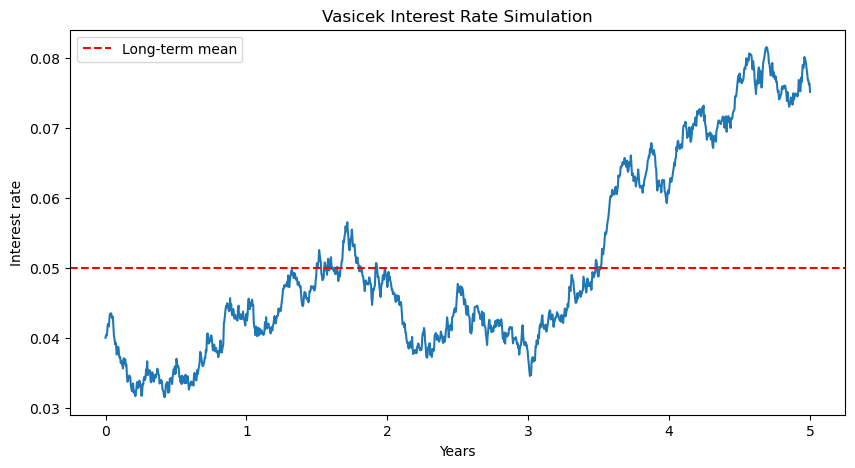

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def vasicek_model(r0, a, b, sigma, T, N, n_sims=1, seed=None):
    if seed is not None:
        np.random.seed(seed)

    dt = T / N
    rates = np.zeros((n_sims, N+1))
    rates[:, 0] = r0

    for t in range(N):
        Z = np.random.normal(0, 1, n_sims)
        rates[:, t+1] = (
            rates[:, t]
            + a * (b - rates[:, t]) * dt
            + sigma * np.sqrt(dt) * Z
        )

    return rates

r0 = 0.04      # !!!!!SHORT TERM rate - example current overnight rate
a = 0.3        # speed of mean reversion - so how fast r is pulled towrds b
b = 0.05       # long-run neutral policy rate - level rates tend to revert to over long horizons 
sigma = 0.012  # volatility of everything the model does not explain
T = 5          # years
N = 1250       # daily steps

rates = vasicek_model(r0, a, b, sigma, T, N, seed=42)

time = np.linspace(0, T, N+1)

plt.figure(figsize=(10,5))
plt.plot(time, rates[0])
plt.axhline(b, color='red', linestyle='--', label='Long-term mean')
plt.title("Vasicek Interest Rate Simulation")
plt.xlabel("Years")
plt.ylabel("Interest rate")
plt.legend()
plt.show()

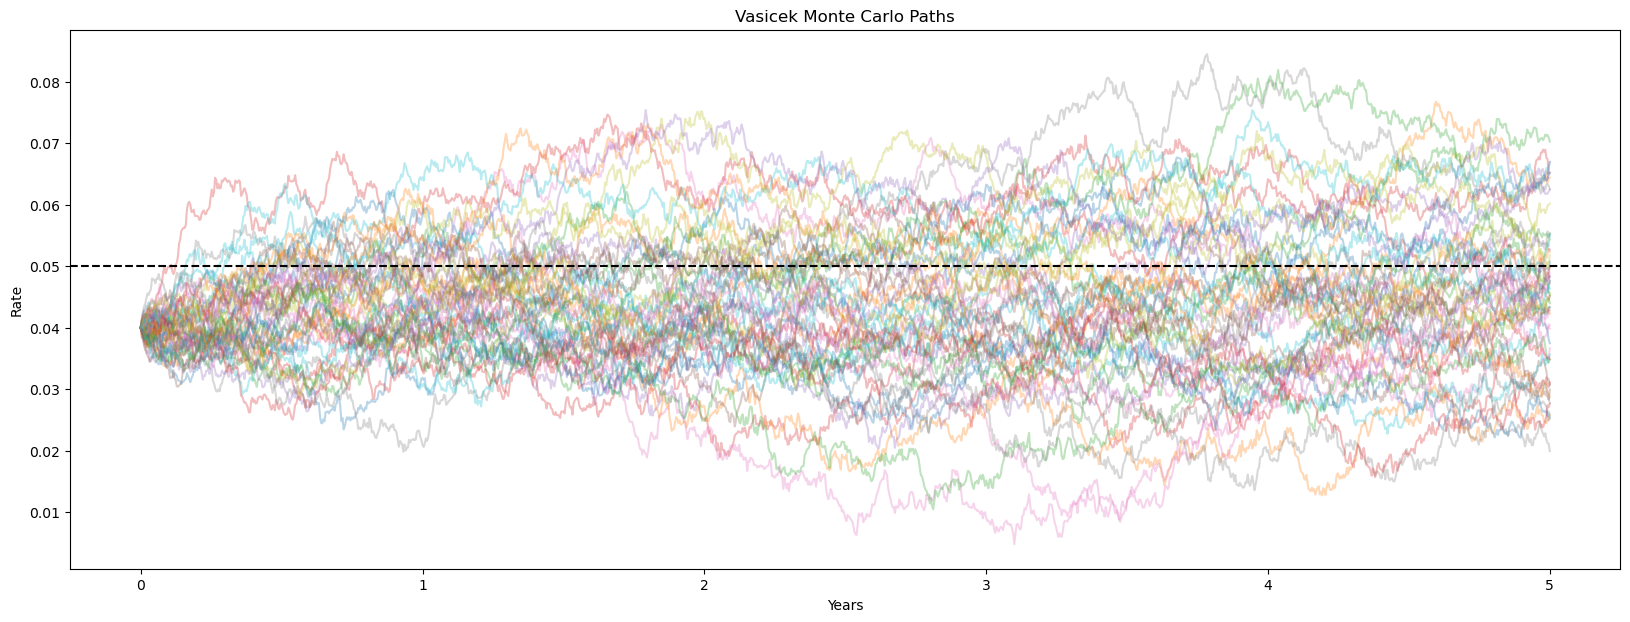

In [2]:
rates_mc = vasicek_model(
    r0, a, b, sigma, T, N, n_sims=500, seed=1
)

plt.figure(figsize=(20,7))
for i in range(50):
    plt.plot(time, rates_mc[i], alpha=0.3)

plt.axhline(b, color='black', linestyle='--')
plt.title("Vasicek Monte Carlo Paths")
plt.xlabel("Years")
plt.ylabel("Rate")
plt.show()

In [3]:
terminal_rates = rates_mc[:, -1]   # last time step of each simulation

bullish_idx = np.argmin(terminal_rates)   # lowest final rate
bearish_idx = np.argmax(terminal_rates)   # highest final rate

bullish_path = rates_mc[bullish_idx]
bearish_path = rates_mc[bearish_idx]

p5 = np.percentile(terminal_rates, 5)
p95 = np.percentile(terminal_rates, 95)

bullish_idx = np.argmin(np.abs(terminal_rates - p5))
bearish_idx = np.argmin(np.abs(terminal_rates - p95))

print(bullish_idx)   # this are the paths number so the 98th and 414 are the closest to the percentiles
print(bearish_idx)

print("Bullish terminal rate:", terminal_rates[bullish_idx])
print("Bearish terminal rate:", terminal_rates[bearish_idx])


98
414
Bullish terminal rate: 0.02437319642497058
Bearish terminal rate: 0.07343643470705327


## 2. Cox-Ingersoll-Ross (CIR) Short Rate Model

### Overview

This section implements the Cox-Ingersoll-Ross (CIR) model, a square-root diffusion process designed to overcome the main limitation of the Vasicek model: the possibility of negative interest rates.

The CIR model ensures that interest rates remain strictly positive and introduces state-dependent volatility.

### Model Characteristics

- Mean-reverting stochastic process
- Strictly positive interest rates
- Volatility proportional to √r (state-dependent)
- Satisfies the Feller condition for boundary behavior

### Implementation Details

The model simulates interest rate paths using a discretized square-root diffusion process:

- Prevents negative rates via truncation
- Applies stochastic shocks scaled by current rate level
- Ensures economically consistent rate behavior

### Outputs

- Monte Carlo interest rate paths
- Distribution of future short rates
- Path variability under different volatility regimes

### Interpretation

Compared to Vasicek, the CIR model produces more realistic interest rate behavior, particularly in low-rate environments where Gaussian models may become economically inconsistent.

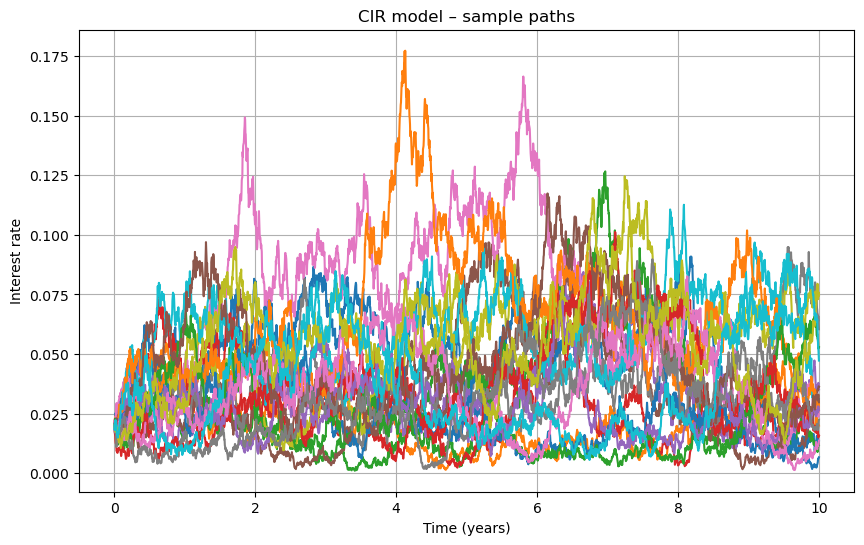

In [4]:
# CIR implementation = the Feller condition = rates stay strictly positive and zero is never achieved

import numpy as np
import matplotlib.pyplot as plt

def simulate_cir(
    x0,       # initial value
    kappa,    # speed of mean reversion
    theta,    # long-run mean
    sigma,    # volatility
    T,        # time horizon (years)
    n_steps,  # number of time steps
    n_paths,  # number of Monte Carlo paths
    seed=42
):
    np.random.seed(seed)
    dt = T / n_steps
    X = np.zeros((n_steps + 1, n_paths))
    X[0] = x0

    for t in range(1, n_steps + 1):
        Z = np.random.normal(size=n_paths)
        X_prev = np.maximum(X[t-1], 0)  # prevent negatives
        X[t] = (
            X_prev
            + kappa * (theta - X_prev) * dt
            + sigma * np.sqrt(X_prev) * np.sqrt(dt) * Z
        )
        X[t] = np.maximum(X[t], 0)

    return X

# Model parameters
x0 = 0.02        # 2% initial rate
kappa = 0.6      # moderate mean reversion
theta = 0.04     # long-run rate = 4%
sigma = 0.15     # volatility

# Simulation parameters
T = 10           # 10 years
n_steps = 2500   # daily-ish
n_paths = 500

X = simulate_cir(x0, kappa, theta, sigma, T, n_steps, n_paths)

time = np.linspace(0, T, n_steps + 1)

plt.figure(figsize=(10,6))
for i in range(20):
    plt.plot(time, X[:, i])
plt.xlabel("Time (years)")
plt.ylabel("Interest rate")
plt.title("CIR model – sample paths")
plt.grid(True)
plt.show()

## 3. Zero-Coupon Bond Pricing and Yield Curve (CIR Framework)

### Overview

This section derives zero-coupon bond prices and the corresponding yield curve under the CIR short-rate model.

The CIR model allows for closed-form solutions for bond pricing under affine term structure assumptions.

### Theoretical Framework

Under the CIR model, zero-coupon bond prices take an exponential-affine form:

- Bond prices depend on current short rate and model parameters
- Closed-form solutions avoid numerical simulation
- Yields are derived from log-transformed bond prices

### Key Outputs

- Zero-coupon bond prices across maturities
- Model-implied yield curve
- Term structure dynamics under CIR assumptions

### Market Comparison

The CIR-implied yield curve is compared against observed market yields to assess:

- Model calibration quality
- Term structure fit
- Deviations between theoretical and market pricing

### Interpretation

This framework connects stochastic short-rate dynamics directly to observable fixed income instruments.

It provides a complete pipeline:

> Short rate dynamics → bond pricing → yield curve construction → market comparison

### Key Insight

The CIR model embeds a structural relationship between:
- Interest rate dynamics
- Bond valuation
- Yield curve shape

making it a foundational tool in fixed income modelling and interest rate risk analysis.

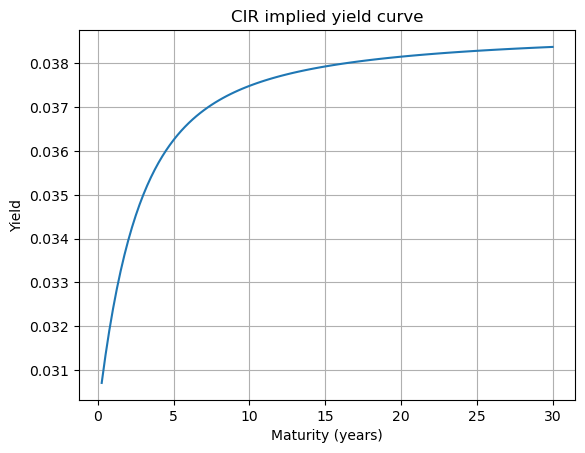

In [5]:
# ZERO COUPON BOND YIELD CURVE and PRICE FROM CIR

import numpy as np
import matplotlib.pyplot as plt

def cir_zcb_price(r, tau, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    B = (2 * (np.exp(gamma * tau) - 1)
        / ((gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma)
    )

    A = ((2 * gamma * np.exp((kappa + gamma) * tau / 2))
        / ((gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma)
    ) ** (2 * kappa * theta / sigma**2)

    return A * np.exp(-B * r)

r0 = 0.03
kappa = 0.6
theta = 0.04
sigma = 0.15

maturities = np.linspace(0.25, 30, 120)
prices = [cir_zcb_price(r0, t, kappa, theta, sigma) for t in maturities]
yields = [-np.log(p)/t for p, t in zip(prices, maturities)]

plt.plot(maturities, yields)
plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.title("CIR implied yield curve")
plt.grid()
plt.show()

In [6]:
def cir_zero_coupon_price(r0, T, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    
    B = (2 * (np.exp(gamma * T) - 1)) / ((gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma)
    A = ((2 * gamma * np.exp((gamma + kappa) * T / 2)) / ((gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma))**(2 * kappa * theta / sigma**2)
    
    P = A * np.exp(-B * r0)
    return P

# Example:
r0 = 0.03       # current short rate
T = 5           # 5-year bond
kappa = 0.1
theta = 0.05
sigma = 0.02

price = cir_zero_coupon_price(r0, T, kappa, theta, sigma)
print("Zero-coupon bond price:", price)

Zero-coupon bond price: 0.842722493853384


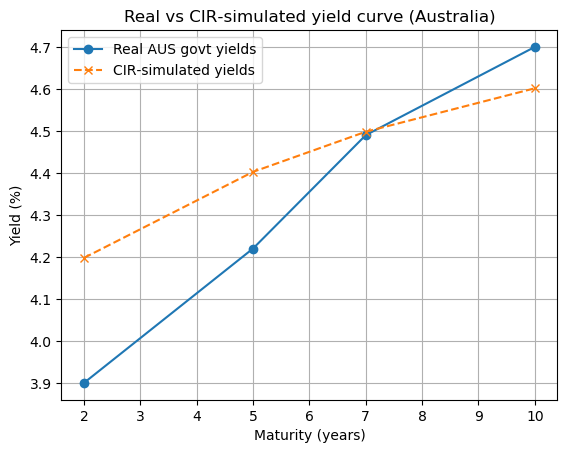

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Part 1: load real data (example using TradingEconomics CSV export or manual data) ---
# Here: I manually created a small sample for illustration; in practice load from file or API
maturities = np.array([2, 5, 7, 10])  # in years
real_yields = np.array([3.90, 4.22, 4.49, 4.70])  # example yields in %, convert to decimal below

real_yields = real_yields / 100.0

# --- Part 2: define CIR zero‑coupon price function + yield generator (assuming flat r0 = current short rate) ---
def cir_zero_coupon_price(r0, T, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    B = (2 * (np.exp(gamma * T) - 1)) / ((gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma)
    A = ((2 * gamma * np.exp((gamma + kappa) * T / 2)) / ((gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma))**(2 * kappa * theta / sigma**2)
    P = A * np.exp(-B * r0)
    return P

def cir_yield(r0, T, kappa, theta, sigma):
    P = cir_zero_coupon_price(r0, T, kappa, theta, sigma)
    return -np.log(P) / T

# Example CIR parameters (tune to match approximate current market rates)
r0 = 0.04     # 4% – you could set this to near the short end yield or cash rate
kappa = 0.23
theta = 0.05
sigma = 0.02

cir_yields = np.array([cir_yield(r0, T, kappa, theta, sigma) for T in maturities])

# --- Part 3: plot real vs CIR yield curve ---
plt.plot(maturities, real_yields*100, 'o-', label='Real AUS govt yields')
plt.plot(maturities, cir_yields*100, 'x--', label='CIR‑simulated yields')
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title('Real vs CIR‑simulated yield curve (Australia)')
plt.legend()
plt.grid(True)
plt.show()